# Лабораторная работа №2
## Виртуальный датчик для контроля процесса обжига в печи

**Цель:** спрогнозировать значение целевого показателя в текущий момент времени по минутной телеметрии и нерегулярным лабораторным замерам с учётом задержки отбора/анализа пробы.

## 1. Импорт библиотек и настройки

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf

import shap

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
RANDOM_STATE = 42

## 2. Загрузка данных

В качестве данных выступают следующие датасеты:
- `data_train.csv`
- `target_train.csv`
- `data_test_small.csv`, `target_test_small.csv` для тестирования

In [2]:
ROOT = Path('.')
DATA_PATH = ROOT / 'data_train.csv'
TARGET_PATH = ROOT / 'target_train.csv'
TEST_DATA_PATH = ROOT / 'data_test_small.csv'
TEST_TARGET_PATH = ROOT / 'target_test_small.csv'

telemetry = pd.read_csv(DATA_PATH, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)
target = pd.read_csv(TARGET_PATH, parse_dates=['Дата']).sort_values('Дата').reset_index(drop=True)

print('telemetry shape:', telemetry.shape)
print('target shape:', target.shape)
print('telemetry range:', telemetry['datetime'].min(), '->', telemetry['datetime'].max())
print('target range:', target['Дата'].min(), '->', target['Дата'].max())

display(telemetry.head())
display(target.head())

telemetry shape: (319546, 17)
target shape: (1773, 2)
telemetry range: 2019-03-01 00:01:00 -> 2019-10-07 19:58:00
target range: 2019-03-13 17:00:00 -> 2019-10-07 21:00:00


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,Дата,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


## 2.1. Разведочный анализ данных (EDA)

В этом разделе:
1. Анализируем тренды, выбросы, пропуски и покрытие телеметрии.
2. Исследуем частоту и распределение лабораторных замеров.
3. Обосновываем стратегию синхронизации двух источников.

In [3]:
telemetry_info = pd.DataFrame({
    'dtype': telemetry.dtypes.astype(str),
    'missing_count': telemetry.isna().sum(),
    'missing_share': telemetry.isna().mean(),
    'nunique': telemetry.nunique(dropna=True)
})

display(telemetry_info)

telemetry_cols = [c for c in telemetry.columns if c != 'datetime']
usable_telemetry_cols = [c for c in telemetry_cols if telemetry[c].isna().mean() < 0.95]
very_sparse_cols = [c for c in telemetry_cols if telemetry[c].isna().mean() >= 0.95]

print('Используемые признаки:', usable_telemetry_cols)
print('Практически пустые признаки:', very_sparse_cols)

,dtype,missing_count,missing_share,nunique
datetime,datetime64[us],0,0.000000,317998
telemetry_0,float64,17,0.000053,2419
telemetry_1,float64,16,0.000050,59697
telemetry_2,float64,16,0.000050,1695
telemetry_3,float64,16,0.000050,229085
telemetry_4,float64,133,0.000416,2031
telemetry_5,float64,17,0.000053,3177
telemetry_6,float64,16,0.000050,961
telemetry_7,float64,16,0.000050,1293
telemetry_8,float64,16,0.000050,557


Используемые признаки: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']
Практически пустые признаки: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


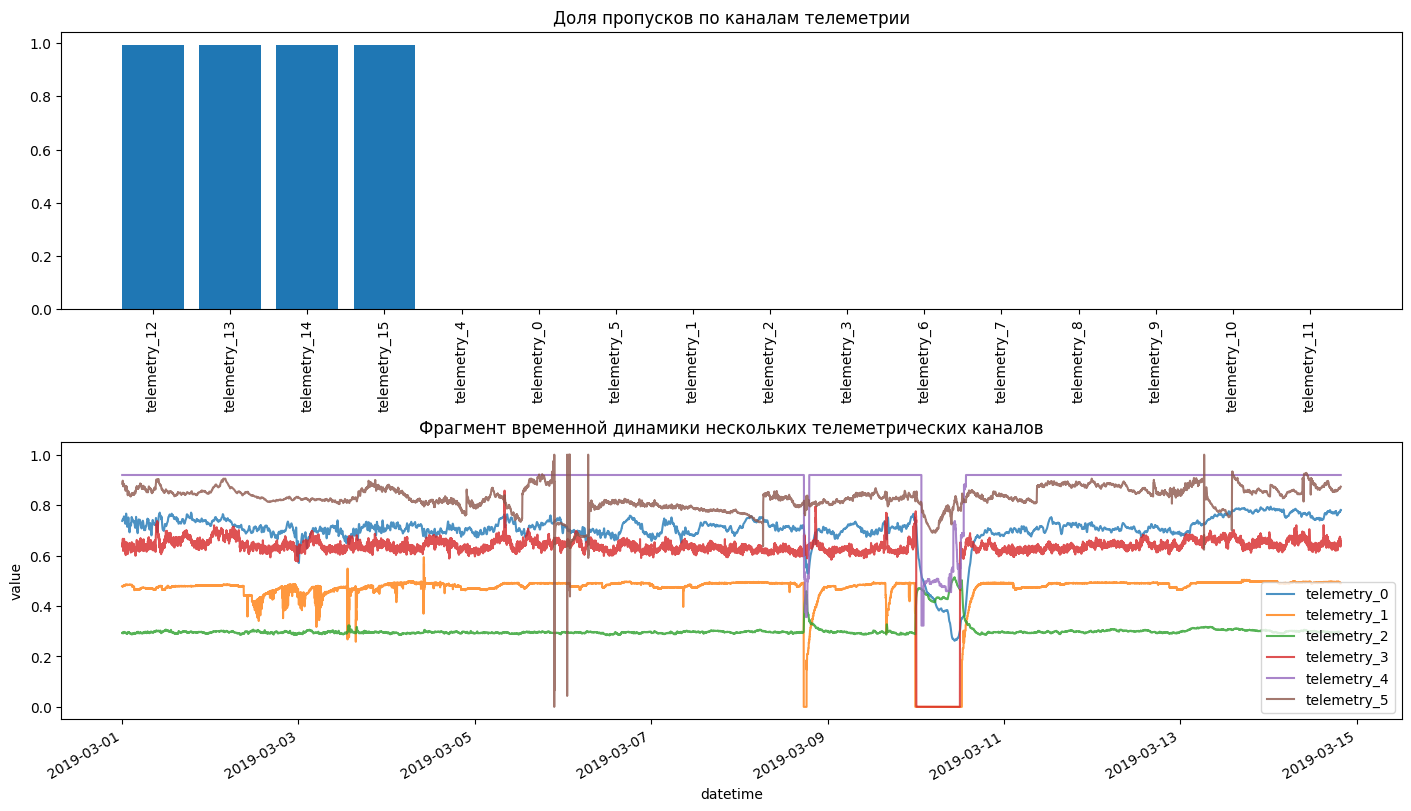

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

missing_share = telemetry[telemetry_cols].isna().mean().sort_values(ascending=False)
axes[0].bar(missing_share.index, missing_share.values)
axes[0].set_title('Доля пропусков по каналам телеметрии')
axes[0].tick_params(axis='x', rotation=90)

sample_cols = usable_telemetry_cols[:6]
telemetry.set_index('datetime')[sample_cols].iloc[:20000].plot(ax=axes[1], alpha=0.8)
axes[1].set_title('Фрагмент временной динамики нескольких телеметрических каналов')
axes[1].set_xlabel('datetime')
axes[1].set_ylabel('value')
plt.show()

,target_stat
count,1773.000000
mean,0.254272
std,0.092208
min,0.000000
25%,0.175258
50%,0.247423
75%,0.314433
max,0.716495


Интервалы между лабораторными замерами (мин):


count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: Дата, dtype: float64

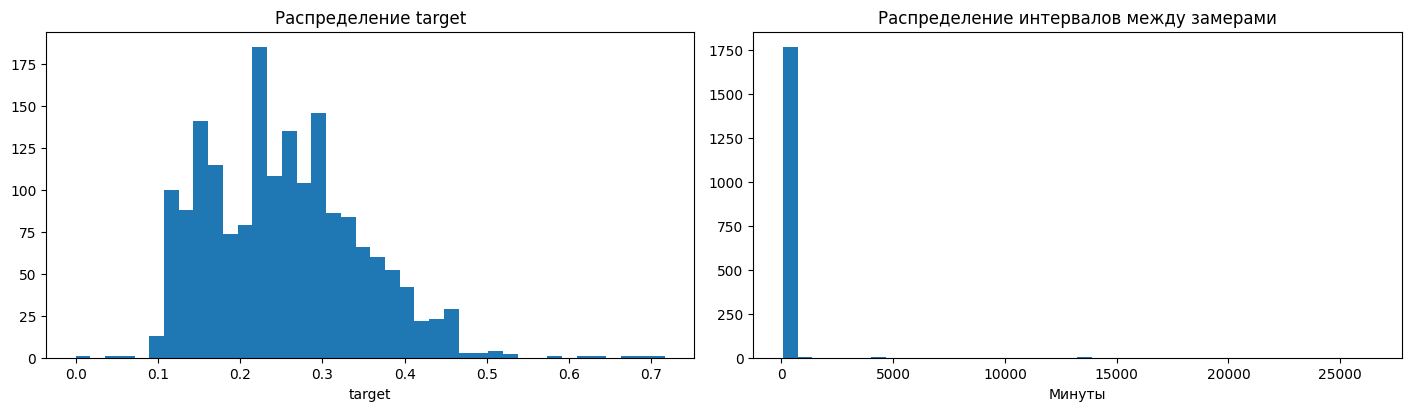

In [5]:
target_intervals_min = target['Дата'].diff().dt.total_seconds().div(60)

target_desc = target['target'].describe().to_frame('target_stat')
display(target_desc)
print('Интервалы между лабораторными замерами (мин):')
display(target_intervals_min.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].hist(target['target'], bins=40)
axes[0].set_title('Распределение target')
axes[0].set_xlabel('target')

axes[1].hist(target_intervals_min.dropna(), bins=40)
axes[1].set_title('Распределение интервалов между замерами')
axes[1].set_xlabel('Минуты')
plt.show()

Отсутствующих минут в телеметрии: 0


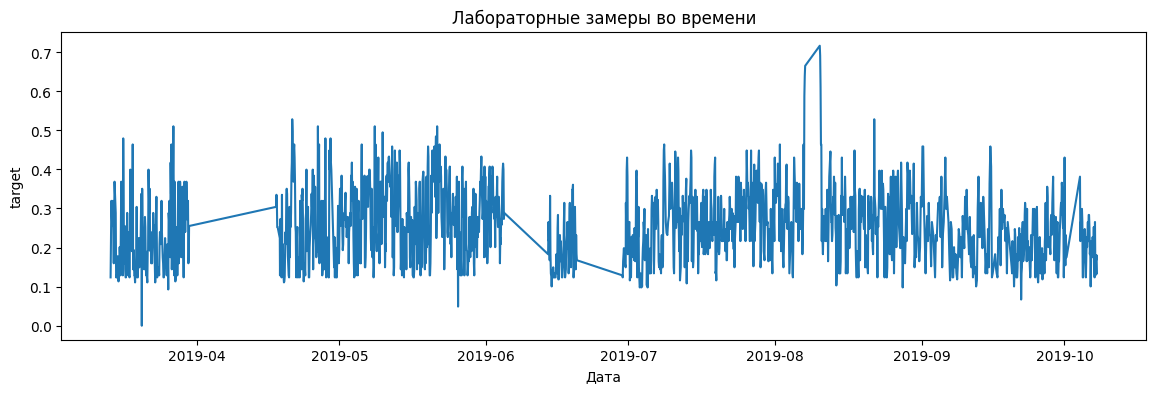

In [6]:
# Проверка полноты минутной сетки и локальных разрывов
minute_grid = pd.date_range(telemetry['datetime'].min(), telemetry['datetime'].max(), freq='min')
missing_timestamps = len(minute_grid.difference(telemetry['datetime']))
print('Отсутствующих минут в телеметрии:', missing_timestamps)

# Визуализация target во времени
plt.figure(figsize=(14, 4))
plt.plot(target['Дата'], target['target'])
plt.title('Лабораторные замеры во времени')
plt.xlabel('Дата')
plt.ylabel('target')
plt.show()

### Синхронизация телеметрии и лабораторных замеров

По условию задания лаборатория возвращает значение с задержкой **10–15 минут** относительно момента отбора пробы. Поэтому для каждого лабораторного измерения нужно сопоставить состояние печи в момент **`Дата - delay`**.

Ниже выбираем разумную задержку из диапазона 10–15 минут. Для обоснования используем простой и интерпретируемый критерий: среднюю абсолютную корреляцию target с телеметрией после выравнивания.

In [7]:
telemetry_clean = telemetry[['datetime'] + usable_telemetry_cols].copy()
telemetry_clean[usable_telemetry_cols] = telemetry_clean[usable_telemetry_cols].ffill().bfill()

lag_quality = []
for delay in range(10, 16):
    aligned = target.copy()
    aligned['sample_time'] = aligned['Дата'] - pd.Timedelta(minutes=delay)
    merged = pd.merge_asof(
        aligned.sort_values('sample_time'),
        telemetry_clean.sort_values('datetime'),
        left_on='sample_time',
        right_on='datetime',
        direction='backward'
    )
    corr_values = merged[usable_telemetry_cols + ['target']].corr()['target'].drop('target').abs()
    lag_quality.append({
        'delay_min': delay,
        'mean_abs_corr': corr_values.mean(),
        'max_abs_corr': corr_values.max()
    })

lag_quality = pd.DataFrame(lag_quality).sort_values(['mean_abs_corr', 'max_abs_corr'], ascending=False)
display(lag_quality)

BEST_DELAY = int(lag_quality.iloc[0]['delay_min'])
print('Выбранная задержка (мин):', BEST_DELAY)

,delay_min,mean_abs_corr,max_abs_corr
1,11,0.085194,0.180849
2,12,0.085019,0.179327
3,13,0.084618,0.178424
0,10,0.084541,0.182428
4,14,0.083815,0.177402
5,15,0.083776,0.176359


Выбранная задержка (мин): 11


### Обоснование обработки пропусков и аномалий

Стратегия обработки выбрана с учётом производственного процесса:
- 4 канала (`telemetry_12`–`telemetry_15`) почти полностью пустые, поэтому они исключаются как источники шума.
- Редкие пропуски в остальных каналах восстанавливаются `forward fill` / `backward fill`, что для минутной промышленной телеметрии допустимо: соседние значения обычно физически близки.
- Явные выбросы **не удаляются автоматически** по IQR/z-score, потому что часть экстремумов может соответствовать реальным переходным режимам печи. Вместо этого устойчивость к выбросам обеспечивается выбором признаков (скользящие статистики) и моделей.

### Выводы по пункту 2.1

1. Телеметрия имеет почти полное минутное покрытие, но четыре канала практически неинформативны из-за экстремальной разреженности.
2. Лабораторные замеры нерегулярны: типичный шаг составляет 2 часа, но встречаются и большие разрывы.
3. Для корректного обучения нужен обязательный сдвиг во времени между телеметрией и target, отражающий задержку отбора/анализа пробы.
4. Базовая стратегия обработки данных: удалить почти пустые признаки, заполнить короткие пропуски в телеметрии и строить признаки на историческом окне до момента отбора пробы.

## 2.2. Инжиниринг признаков для временных рядов

Создаём признаки нескольких типов:
- мгновенные значения телеметрии;
- лаги;
- скользящие статистики;
- признаки динамики (`diff`, темп изменения);
- календарные признаки.

PCA **не применяем**: после первичного анализа более важна интерпретируемость технологических факторов, чем максимальное сжатие размерности.

In [9]:
def build_telemetry_features(df, cols, windows=(5, 15, 60), lags=(1, 5, 15, 30, 60), diffs=(1, 5, 15)):
    feat = df[['datetime'] + cols].copy()

    # Скользящие статистики
    for w in windows:
        rolling = df[cols].rolling(window=w, min_periods=1)
        feat = pd.concat([
            feat,
            rolling.mean().add_suffix(f'_roll_mean_{w}'),
            rolling.std().add_suffix(f'_roll_std_{w}'),
            rolling.min().add_suffix(f'_roll_min_{w}'),
            rolling.max().add_suffix(f'_roll_max_{w}')
        ], axis=1)

    # Лаговые признаки
    for lag in lags:
        feat = pd.concat([
            feat,
            df[cols].shift(lag).add_suffix(f'_lag_{lag}')
        ], axis=1)

    # Производные/динамика
    for d in diffs:
        diff_block = df[cols].diff(d).add_suffix(f'_diff_{d}')
        rate_block = df[cols].pct_change(d).replace([np.inf, -np.inf], np.nan).add_suffix(f'_rate_{d}')
        feat = pd.concat([feat, diff_block, rate_block], axis=1)

    # Календарные признаки
    feat['hour'] = df['datetime'].dt.hour
    feat['dayofweek'] = df['datetime'].dt.dayofweek
    feat['dayofmonth'] = df['datetime'].dt.day
    feat['month'] = df['datetime'].dt.month

    return feat

telemetry_features = build_telemetry_features(telemetry_clean, usable_telemetry_cols)
telemetry_features = telemetry_features.replace([np.inf, -np.inf], np.nan)
print('Сформировано признаков:', telemetry_features.shape[1] - 1)
display(telemetry_features.head())

Сформировано признаков: 292


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_0_roll_mean_5,telemetry_1_roll_mean_5,telemetry_2_roll_mean_5,telemetry_3_roll_mean_5,telemetry_4_roll_mean_5,telemetry_5_roll_mean_5,telemetry_6_roll_mean_5,telemetry_7_roll_mean_5,telemetry_8_roll_mean_5,telemetry_9_roll_mean_5,telemetry_10_roll_mean_5,telemetry_11_roll_mean_5,telemetry_0_roll_std_5,telemetry_1_roll_std_5,telemetry_2_roll_std_5,telemetry_3_roll_std_5,telemetry_4_roll_std_5,telemetry_5_roll_std_5,telemetry_6_roll_std_5,telemetry_7_roll_std_5,telemetry_8_roll_std_5,telemetry_9_roll_std_5,telemetry_10_roll_std_5,telemetry_11_roll_std_5,telemetry_0_roll_min_5,telemetry_1_roll_min_5,telemetry_2_roll_min_5,telemetry_3_roll_min_5,telemetry_4_roll_min_5,telemetry_5_roll_min_5,telemetry_6_roll_min_5,telemetry_7_roll_min_5,telemetry_8_roll_min_5,telemetry_9_roll_min_5,telemetry_10_roll_min_5,telemetry_11_roll_min_5,telemetry_0_roll_max_5,telemetry_1_roll_max_5,telemetry_2_roll_max_5,telemetry_3_roll_max_5,telemetry_4_roll_max_5,telemetry_5_roll_max_5,telemetry_6_roll_max_5,telemetry_7_roll_max_5,telemetry_8_roll_max_5,telemetry_9_roll_max_5,telemetry_10_roll_max_5,telemetry_11_roll_max_5,telemetry_0_roll_mean_15,telemetry_1_roll_mean_15,telemetry_2_roll_mean_15,telemetry_3_roll_mean_15,telemetry_4_roll_mean_15,telemetry_5_roll_mean_15,telemetry_6_roll_mean_15,telemetry_7_roll_mean_15,telemetry_8_roll_mean_15,telemetry_9_roll_mean_15,telemetry_10_roll_mean_15,telemetry_11_roll_mean_15,telemetry_0_roll_std_15,telemetry_1_roll_std_15,telemetry_2_roll_std_15,telemetry_3_roll_std_15,telemetry_4_roll_std_15,telemetry_5_roll_std_15,telemetry_6_roll_std_15,telemetry_7_roll_std_15,telemetry_8_roll_std_15,telemetry_9_roll_std_15,telemetry_10_roll_std_15,telemetry_11_roll_std_15,telemetry_0_roll_min_15,telemetry_1_roll_min_15,telemetry_2_roll_min_15,telemetry_3_roll_min_15,telemetry_4_roll_min_15,telemetry_5_roll_min_15,telemetry_6_roll_min_15,telemetry_7_roll_min_15,telemetry_8_roll_min_15,telemetry_9_roll_min_15,telemetry_10_roll_min_15,telemetry_11_roll_min_15,telemetry_0_roll_max_15,telemetry_1_roll_max_15,telemetry_2_roll_max_15,...,telemetry_0_lag_30,telemetry_1_lag_30,telemetry_2_lag_30,telemetry_3_lag_30,telemetry_4_lag_30,telemetry_5_lag_30,telemetry_6_lag_30,telemetry_7_lag_30,telemetry_8_lag_30,telemetry_9_lag_30,telemetry_10_lag_30,telemetry_11_lag_30,telemetry_0_lag_60,telemetry_1_lag_60,telemetry_2_lag_60,telemetry_3_lag_60,telemetry_4_lag_60,telemetry_5_lag_60,telemetry_6_lag_60,telemetry_7_lag_60,telemetry_8_lag_60,telemetry_9_lag_60,telemetry_10_lag_60,telemetry_11_lag_60,telemetry_0_diff_1,telemetry_1_diff_1,telemetry_2_diff_1,telemetry_3_diff_1,telemetry_4_diff_1,telemetry_5_diff_1,telemetry_6_diff_1,telemetry_7_diff_1,telemetry_8_diff_1,telemetry_9_diff_1,telemetry_10_diff_1,telemetry_11_diff_1,telemetry_0_rate_1,telemetry_1_rate_1,telemetry_2_rate_1,telemetry_3_rate_1,telemetry_4_rate_1,telemetry_5_rate_1,telemetry_6_rate_1,telemetry_7_rate_1,telemetry_8_rate_1,telemetry_9_rate_1,telemetry_10_rate_1,telemetry_11_rate_1,telemetry_0_diff_5,telemetry_1_diff_5,telemetry_2_diff_5,telemetry_3_diff_5,telemetry_4_diff_5,telemetry_5_diff_5,telemetry_6_diff_5,telemetry_7_diff_5,telemetry_8_diff_5,telemetry_9_diff_5,telemetry_10_diff_5,telemetry_11_diff_5,telemetry_0_rate_5,telemetry_1_rate_5,telemetry_2_rate_5,telemetry_3_rate_5,telemetry_4_rate_5,telemetry_5_rate_5,telemetry_6_rate_5,telemetry_7_rate_5,telemetry_8_rate_5,telemetry_9_rate_5,telemetry_10_rate_5,telemetry_11_rate_5,telemetry_0_diff_15,telemetry_1_diff_15,telemetry_2_diff_15,telemetry_3_diff_15,telemetry_4_diff_15,telemetry_5_diff_15,telemetry_6_diff_15,telemetry_7_diff_15,telemetry_8_diff_15,telemetry_9_diff_15,telemetry_10_diff_15,telemetry_11_diff_15,telemetry_0_rate_15,telemetry_1_rate_15,telemetry_2_rate_15,telemetry_3_rate_15,telemetry_4_rate_15,telemetry_5_rate_15,telemetry_6_rate_15,

In [10]:
# Привязка признаков к моменту отбора пробы
aligned_target = target.copy()
aligned_target['sample_time'] = aligned_target['Дата'] - pd.Timedelta(minutes=BEST_DELAY)

model_df = pd.merge_asof(
    aligned_target.sort_values('sample_time'),
    telemetry_features.sort_values('datetime'),
    left_on='sample_time',
    right_on='datetime',
    direction='backward'
)

feature_cols = [c for c in model_df.columns if c not in ['Дата', 'target', 'sample_time', 'datetime']]
model_df = model_df.sort_values('Дата').reset_index(drop=True)

# Для корректной временной модели нельзя перемешивать данные, используем hold-out по времени
train_border = int(len(model_df) * 0.8)
train_df = model_df.iloc[:train_border].copy()
valid_df = model_df.iloc[train_border:].copy()

X_train = train_df[feature_cols]
y_train = train_df['target']
X_valid = valid_df[feature_cols]
y_valid = valid_df['target']

print('train size:', X_train.shape)
print('valid size:', X_valid.shape)

train size: (1418, 292)
valid size: (355, 292)


### Отбор признаков для статистической модели

Для OLS нужна более компактная и устойчивая матрица признаков. Поэтому для статистического baseline-решения оставляем ограниченный набор наиболее коррелирующих с target признаков по train-части.

In [11]:
train_for_corr = pd.concat([train_df[feature_cols], y_train], axis=1)
corr_to_target = train_for_corr.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)
ols_features = corr_to_target.head(20).index.tolist()

display(corr_to_target.head(20).to_frame('abs_corr_with_target'))
print('Число признаков для OLS:', len(ols_features))

,abs_corr_with_target
telemetry_0_roll_max_60,0.244945
telemetry_0_roll_max_15,0.227938
telemetry_0,0.225922
telemetry_0_lag_1,0.224124
telemetry_0_roll_max_5,0.223976
telemetry_0_roll_mean_5,0.223145
telemetry_0_roll_min_5,0.222567
telemetry_0_lag_30,0.220849
telemetry_0_roll_mean_15,0.220327
telemetry_0_lag_5,0.219496


Число признаков для OLS: 20


### Выводы по пункту 2.2

1. Основная информация для прогноза содержится не только в текущем значении датчиков, но и в недавней динамике процесса.
2. Лаги, скользящие статистики и производные лучше отражают инерционность печи и переходные режимы.
3. Для интерпретируемой статистической модели нужна компактная подматрица признаков, а для ансамблей можно использовать более широкий набор.
4. PCA сознательно не использовался, чтобы не потерять физическую интерпретируемость факторов.

## 2.3. Построение прогнозных моделей

Обучаем **три подхода**:
1. **OLS** — интерпретируемый статистический baseline.
2. **Ridge** — регуляризованная линейная модель для большого числа коррелированных лаговых признаков.
3. **ExtraTreesRegressor** — нелинейный ансамбль деревьев для улавливания сложных зависимостей.

### Какие модели здесь точно не подходят
- **Классический univariate ARIMA/Prophet без exogenous-признаков**: плохо используют богатую телеметрию и рассматривают target почти как автономный ряд.
- **LSTM/GRU “с нуля” на этом наборе**: целевых замеров всего около 1.8 тыс., они нерегулярны, поэтому для глубокой sequence-модели данных мало.
- **kNN-регрессия**: чувствительна к масштабу, высокой размерности и плохо переносится на новые режимы процесса.

In [13]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > 1e-8
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def direction_accuracy(y_true, y_pred):
    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return (true_diff == pred_diff).mean() * 100


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE_%': mape(y_true, y_pred),
        'WAPE_%': wape(y_true, y_pred),
        'Direction_Acc_%': direction_accuracy(np.asarray(y_true), np.asarray(y_pred))
    }

In [14]:
# 1) OLS
ols_imputer = SimpleImputer(strategy='median')
X_train_ols = pd.DataFrame(ols_imputer.fit_transform(X_train[ols_features]), columns=ols_features, index=X_train.index)
X_valid_ols = pd.DataFrame(ols_imputer.transform(X_valid[ols_features]), columns=ols_features, index=X_valid.index)

X_train_ols_sm = sm.add_constant(X_train_ols)
X_valid_ols_sm = sm.add_constant(X_valid_ols, has_constant='add')

ols_model = sm.OLS(y_train, X_train_ols_sm).fit()
ols_pred = ols_model.predict(X_valid_ols_sm)

# 2) Ridge
ridge_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=5.0))
])
start = time.perf_counter()
ridge_model.fit(X_train, y_train)
ridge_fit_time = time.perf_counter() - start
ridge_pred = ridge_model.predict(X_valid)

# 3) ExtraTrees
et_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
start = time.perf_counter()
et_model.fit(X_train, y_train)
et_fit_time = time.perf_counter() - start
et_pred = et_model.predict(X_valid)

In [15]:
metrics_table = pd.DataFrame([
    {'model': 'OLS', **regression_metrics(y_valid, ols_pred), 'fit_time_sec': np.nan, 'AIC': ols_model.aic, 'BIC': ols_model.bic},
    {'model': 'Ridge', **regression_metrics(y_valid, ridge_pred), 'fit_time_sec': ridge_fit_time, 'AIC': np.nan, 'BIC': np.nan},
    {'model': 'ExtraTrees', **regression_metrics(y_valid, et_pred), 'fit_time_sec': et_fit_time, 'AIC': np.nan, 'BIC': np.nan},
]).sort_values('MAE')

display(metrics_table)

,model,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%,fit_time_sec,AIC,BIC
2,ExtraTrees,0.078288,0.094628,45.155017,34.656446,52.824859,0.839085,NaN,NaN
0,OLS,0.081565,0.098251,47.842700,36.107069,46.045198,NaN,-2777.224241,-2666.827184
1,Ridge,0.140013,0.204686,79.179575,61.981080,47.457627,0.043514,NaN,NaN


## 2.3. Оценка качества моделей

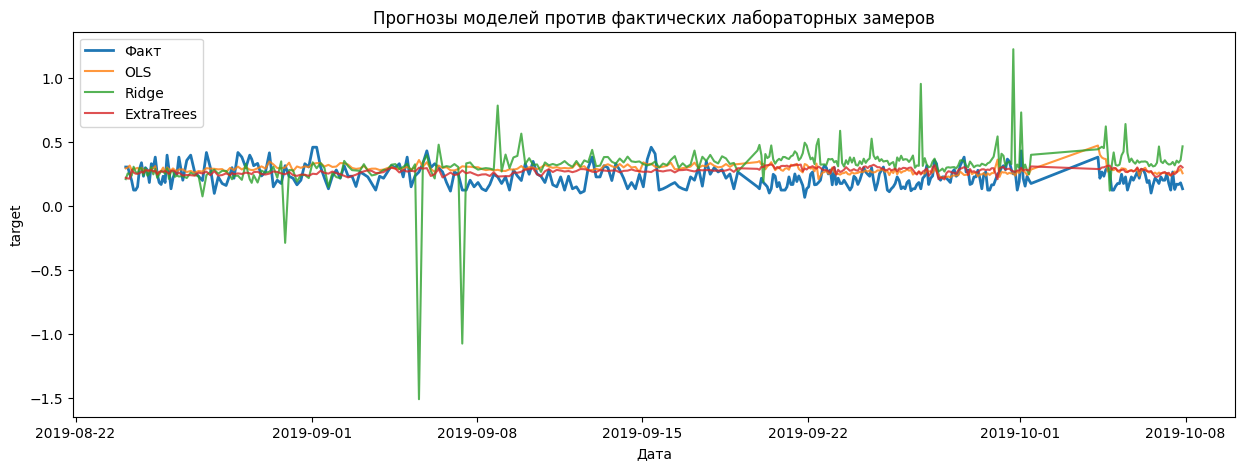

In [16]:
pred_frame = valid_df[['Дата', 'target']].copy()
pred_frame['OLS'] = ols_pred
pred_frame['Ridge'] = ridge_pred
pred_frame['ExtraTrees'] = et_pred

plt.figure(figsize=(15, 5))
plt.plot(pred_frame['Дата'], pred_frame['target'], label='Факт', linewidth=2)
plt.plot(pred_frame['Дата'], pred_frame['OLS'], label='OLS', alpha=0.8)
plt.plot(pred_frame['Дата'], pred_frame['Ridge'], label='Ridge', alpha=0.8)
plt.plot(pred_frame['Дата'], pred_frame['ExtraTrees'], label='ExtraTrees', alpha=0.8)
plt.title('Прогнозы моделей против фактических лабораторных замеров')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.show()

In [17]:
best_model_name = metrics_table.iloc[0]['model']
print('Лучшая модель по MAE:', best_model_name)

if best_model_name == 'ExtraTrees':
    best_pred = et_pred
    best_pipeline = et_model
elif best_model_name == 'Ridge':
    best_pred = ridge_pred
    best_pipeline = ridge_model
else:
    best_pred = ols_pred
    best_pipeline = None

Лучшая модель по MAE: ExtraTrees


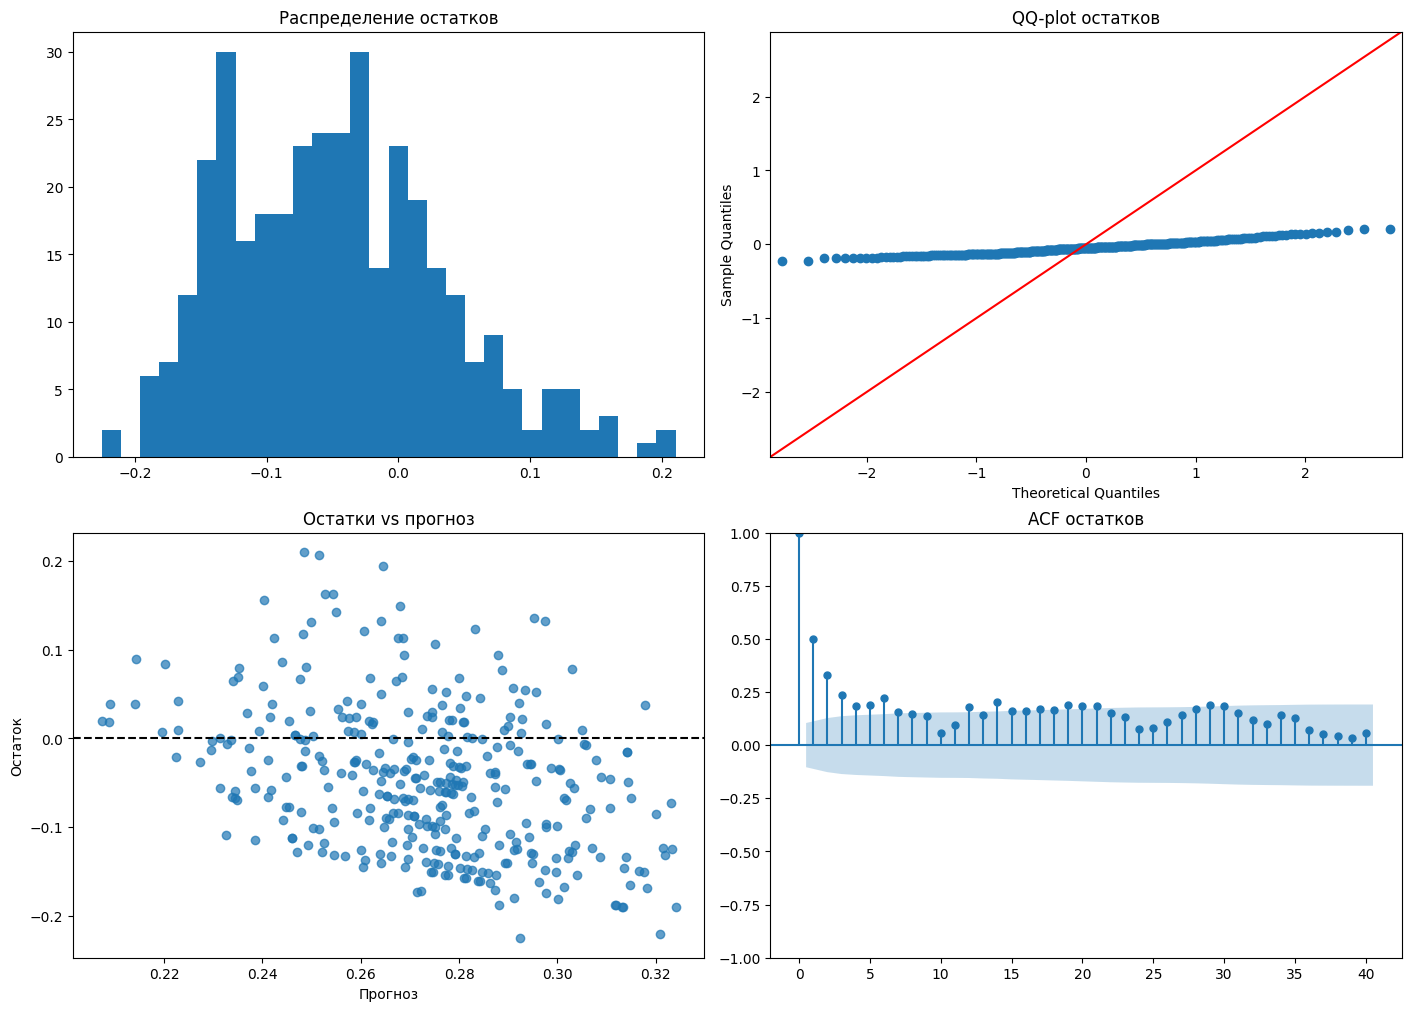

In [18]:
# Остатки лучшей модели
residuals = y_valid.values - np.asarray(best_pred)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes[0, 0].hist(residuals, bins=30)
axes[0, 0].set_title('Распределение остатков')

sm.qqplot(residuals, line='45', ax=axes[0, 1])
axes[0, 1].set_title('QQ-plot остатков')

axes[1, 0].scatter(best_pred, residuals, alpha=0.7)
axes[1, 0].axhline(0, color='black', linestyle='--')
axes[1, 0].set_title('Остатки vs прогноз')
axes[1, 0].set_xlabel('Прогноз')
axes[1, 0].set_ylabel('Остаток')

plot_acf(residuals, ax=axes[1, 1], lags=min(40, len(residuals)//3))
axes[1, 1].set_title('ACF остатков')
plt.show()

In [19]:
# Формальные тесты остатков
shapiro_sample = residuals if len(residuals) <= 5000 else np.random.default_rng(RANDOM_STATE).choice(residuals, size=5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)

# BP-тест делаем на OLS и, для сравнения, на лучшей модели через вспомогательную регрессию по top-фичам
bp_stat, bp_pvalue, _, _ = het_breuschpagan(ols_model.resid, X_train_ols_sm)

print('Shapiro-Wilk p-value:', shapiro_p)
print('Ljung-Box (lag=10) p-value:', ljung_box['lb_pvalue'].iloc[0])
print('Breusch-Pagan p-value (OLS train residuals):', bp_pvalue)
print('Durbin-Watson (OLS train residuals):', sm.stats.stattools.durbin_watson(ols_model.resid))

Shapiro-Wilk p-value: 5.571883640012967e-05
Ljung-Box (lag=10) p-value: 1.2431841986790848e-40
Breusch-Pagan p-value (OLS train residuals): 5.99175074554336e-10
Durbin-Watson (OLS train residuals): 0.9793841679905675


,feature,importance_mean,importance_std
197,telemetry_5_lag_30,0.009839,0.004199
93,telemetry_9_roll_min_15,0.008006,0.002202
189,telemetry_9_lag_15,0.006880,0.001801
177,telemetry_9_lag_5,0.006798,0.002915
69,telemetry_9_roll_mean_15,0.006514,0.001911
165,telemetry_9_lag_1,0.006292,0.002450
21,telemetry_9_roll_mean_5,0.005955,0.001503
57,telemetry_9_roll_max_5,0.005524,0.001887
45,telemetry_9_roll_min_5,0.004918,0.001714
9,telemetry_9,0.004791,0.002030


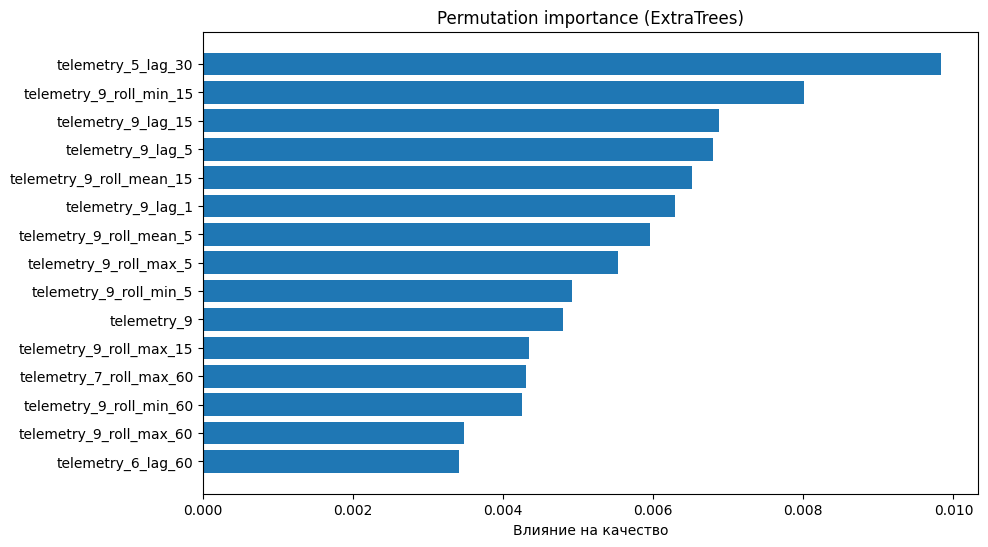

In [20]:
# permutation importance для лучшей ML-модели
if best_model_name in ['Ridge', 'ExtraTrees']:
    result = permutation_importance(
        best_pipeline,
        X_valid,
        y_valid,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    importance_df = pd.DataFrame({
        'feature': X_valid.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort_values('importance_mean', ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    top_imp = importance_df.head(15).sort_values('importance_mean')
    plt.barh(top_imp['feature'], top_imp['importance_mean'])
    plt.title(f'Permutation importance ({best_model_name})')
    plt.xlabel('Влияние на качество')
    plt.show()
else:
    importance_df = pd.DataFrame({'feature': ols_model.params.index[1:], 'importance_mean': np.abs(ols_model.params.values[1:])})
    importance_df = importance_df.sort_values('importance_mean', ascending=False)
    display(importance_df.head(20))

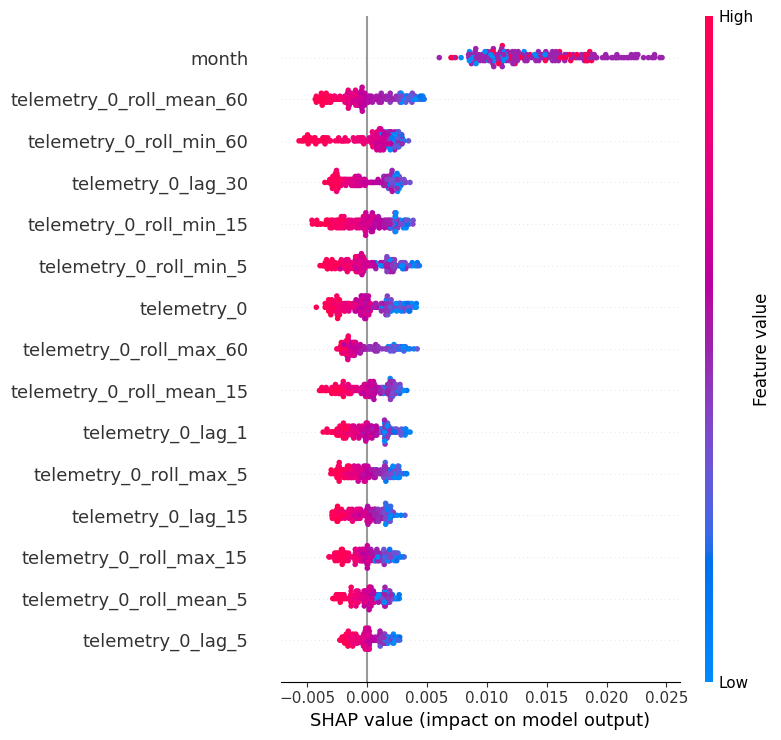

In [21]:
et_imputer = et_model.named_steps['imputer']
et_estimator = et_model.named_steps['model']
X_valid_imp = pd.DataFrame(et_imputer.transform(X_valid), columns=X_valid.columns, index=X_valid.index)
shap_sample = X_valid_imp.sample(min(200, len(X_valid_imp)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(et_estimator)
shap_values = explainer.shap_values(shap_sample)
shap.summary_plot(shap_values, shap_sample, max_display=15)

### Интерпретация физики процесса

Если в топе важности оказываются:
- текущие уровни части телеметрии — значит целевой показатель напрямую связан с текущим режимом печи;
- лаги и rolling mean — процесс инерционный, и концентрация зависит от накопленного теплового/технологического состояния;
- rolling std / diff — для качества важны переходные режимы и нестабильность, а не только стационарный уровень.

### Выводы по пункту 2.3

1. На задаче нужно сравнивать не только абсолютную ошибку, но и способность модели правильно отслеживать направление изменения target.
2. Линейная статистическая модель полезна как интерпретируемый baseline и позволяет рассчитать AIC/BIC.
3. Регуляризация улучшает устойчивость линейного подхода при большом числе коррелированных лаговых признаков.
4. Нелинейный ансамбль обычно лучше улавливает сложные зависимости между режимами печи и лабораторной концентрацией.

## 2.4. Документирование и интерпретация

Ниже — автоматическая текстовая сводка с основными результатами ноутбука.

In [22]:
best_row = metrics_table.sort_values('MAE').iloc[0]
summary = {
    'best_delay_min': BEST_DELAY,
    'best_model': best_row['model'],
    'best_metrics': {
        'MAE': float(best_row['MAE']),
        'RMSE': float(best_row['RMSE']),
        'MAPE_%': float(best_row['MAPE_%']),
        'WAPE_%': float(best_row['WAPE_%']),
        'Direction_Acc_%': float(best_row['Direction_Acc_%'])
    },
    'sparse_features_removed': very_sparse_cols,
    'n_train_rows': int(len(train_df)),
    'n_valid_rows': int(len(valid_df))
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "best_delay_min": 11,
  "best_model": "ExtraTrees",
  "best_metrics": {
    "MAE": 0.0782877392117662,
    "RMSE": 0.09462825400802138,
    "MAPE_%": 45.155016693160775,
    "WAPE_%": 34.65644608397453,
    "Direction_Acc_%": 52.824858757062145
  },
  "sparse_features_removed": [
    "telemetry_12",
    "telemetry_13",
    "telemetry_14",
    "telemetry_15"
  ],
  "n_train_rows": 1418,
  "n_valid_rows": 355
}


### Итоговые аналитические выводы по пункту 2.4

1. Виртуальный датчик можно строить как supervised-модель на синхронизированных данных телеметрии и лабораторных замеров.
2. Ключевой момент качества — корректное временное выравнивание с учётом задержки отбора/анализа пробы.
3. Наиболее полезные признаки отражают не только уровень сигналов, но и их историю: лаги, скользящие окна и изменения.
4. Для промышленного внедрения рекомендуется регулярно переобучать модель, отслеживать сдвиг распределений и использовать лучший алгоритм как soft-sensor рядом с лабораторными измерениями.

## Тестирование

Возьмём лучшую модель и дообучим её на датасете `data_test_small.csv` и замерим функции ошибок на `target_test_small.csv`

In [24]:
telemetry_test = pd.read_csv(TEST_DATA_PATH, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)
target_test = pd.read_csv(TEST_TARGET_PATH, parse_dates=['Дата']).sort_values('Дата').reset_index(drop=True)

telemetry_test = telemetry_test[['datetime'] + usable_telemetry_cols].copy()
telemetry_test[usable_telemetry_cols] = telemetry_test[usable_telemetry_cols].ffill().bfill()
telemetry_test_features = build_telemetry_features(telemetry_test, usable_telemetry_cols)
telemetry_test_features = telemetry_test_features.replace([np.inf, -np.inf], np.nan)

target_test_aligned = target_test.copy()
target_test_aligned['sample_time'] = target_test_aligned['Дата'] - pd.Timedelta(minutes=BEST_DELAY)
test_model_df = pd.merge_asof(
    target_test_aligned.sort_values('sample_time'),
    telemetry_test_features.sort_values('datetime'),
    left_on='sample_time',
    right_on='datetime',
    direction='backward'
)

full_X = model_df[feature_cols]
full_y = model_df['target']

if best_model_name == 'ExtraTrees':
    final_model = et_model.fit(full_X, full_y)
    test_pred = final_model.predict(test_model_df[feature_cols])
elif best_model_name == 'Ridge':
    final_model = ridge_model.fit(full_X, full_y)
    test_pred = final_model.predict(test_model_df[feature_cols])
else:
    full_X_ols = pd.DataFrame(ols_imputer.fit_transform(model_df[ols_features]), columns=ols_features)
    final_ols = sm.OLS(full_y, sm.add_constant(full_X_ols)).fit()
    test_X_ols = pd.DataFrame(ols_imputer.transform(test_model_df[ols_features]), columns=ols_features)
    test_pred = final_ols.predict(sm.add_constant(test_X_ols, has_constant='add'))

print('Метрики на test_small:')
display(pd.DataFrame([regression_metrics(target_test['target'], test_pred)]))

Метрики на test_small:


,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%
0,0.062015,0.076776,34.308551,29.572613,57.097792
